<a href="https://colab.research.google.com/github/Comfortade/mgnify-protein-ssn-prototype/blob/main/notebooks/Prototype_with_500proteins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Environment Setup
Installing MMseqs2 for sequence alignment.


In [ ]:
!wget https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz -O mmseqs.tar.gz
!tar -xvf mmseqs.tar.gz
import os
os.environ['PATH'] += ":" + os.getcwd() + "/mmseqs/bin"
!cp mmseqs/bin/mmseqs /usr/local/bin/

--2026-03-27 15:38:21--  https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
Resolving mmseqs.com (mmseqs.com)... 158.247.200.62
Connecting to mmseqs.com (mmseqs.com)|158.247.200.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19141549 (18M) [application/octet-stream]
Saving to: ‘mmseqs.tar.gz’

mmseqs.tar.gz       100%[===================>]  18.25M  14.0MB/s    in 1.3s    

2026-03-27 15:38:23 (14.0 MB/s) - ‘mmseqs.tar.gz’ saved [19141549/19141549]

mmseqs/
mmseqs/README.md
mmseqs/LICENSE.md
mmseqs/userguide.pdf
mmseqs/bin/
mmseqs/bin/mmseqs
mmseqs/matrices/
mmseqs/matrices/PAM100.out
mmseqs/matrices/PAM60.out
mmseqs/matrices/PAM160.out
mmseqs/matrices/blosum85.out
mmseqs/matrices/VTML120.out
mmseqs/matrices/VTML20.out
mmseqs/matrices/blosum80.out
mmseqs/matrices/blosum95.out
mmseqs/matrices/blosum30.out
mmseqs/matrices/blosum35.out
mmseqs/matrices/PAM180.out
mmseqs/matrices/blosum50.out
mmseqs/matrices/PAM150.out
mmseqs/matrices/VTML40.out
mmseqs/matrices/

In [17]:
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import time

## Data Acquisition: MGnify API Exploration

In [ ]:
def check_interpro_name(id_to_check):
    url = f"https://www.ebi.ac.uk/interpro/api/entry/interpro/{id_to_check}"
    res = requests.get(url)
    if res.status_code == 200:
        name = res.json()['metadata']['name']['name']
        print(f"Yes, ID {id_to_check} is confirmed as: {name}")
    else:
        print(" ID not found. Check the search again.")


check_interpro_name("IPR000871")

Yes, ID IPR000871 is confirmed as: Beta-lactamase, class-A


In [ ]:
interpro_id = "IPR000871"
url = f"https://www.ebi.ac.uk/metagenomics/api/v1/annotations/interpro-identifiers/{interpro_id}/proteins"

print(f" Attempting to fetch from: {url}")

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    proteins = []


    for item in data.get('data', []):
        proteins.append({
            'id': item.get('id'),
            'type': item.get('type'),
            'length': item.get('attributes', {}).get('length', 'N/A')
        })

    df = pd.DataFrame(proteins)
    print(f" Success! Found {len(df)} proteins.")
    print(df.head())
else:
    print(f" Failed again with Status Code: {response.status_code}")

 Attempting to fetch from: https://www.ebi.ac.uk/metagenomics/api/v1/annotations/interpro-identifiers/IPR000871/proteins
 Failed again with Status Code: 500


In [ ]:
import requests
import time

def smart_fetch(interpro_id):
    url = f"https://www.ebi.ac.uk/metagenomics/api/v1/proteins?interpro_id={interpro_id}"

    # We try up to 3 times if the server is having a "500" moment
    for attempt in range(3):
        print(f"Attempt {attempt + 1}: Contacting MGnify...")
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                print(" Data retrieved!")
                return response.json()
            elif response.status_code == 500:
                print(" Server is overwhelmed. Retrying in 5 seconds...")
                time.sleep(5)
            else:
                print(f" Error {response.status_code}")
                break
        except requests.exceptions.Timeout:
            print(" Request timed out. The database is busy.")

    return None

# Test the resilience
result = smart_fetch("IPR000871")

Attempt 1: Contacting MGnify...
 Request timed out. The database is busy.
Attempt 2: Contacting MGnify...
 Request timed out. The database is busy.
Attempt 3: Contacting MGnify...
 Request timed out. The database is busy.


## 3. Metadata Mapping (Prototype Proxy)
Before running the full sequence alignment, this section establishes the metadata structure required for the SSN.



In [ ]:
import pandas as pd
import networkx as nx
import random
from IPython.display import HTML

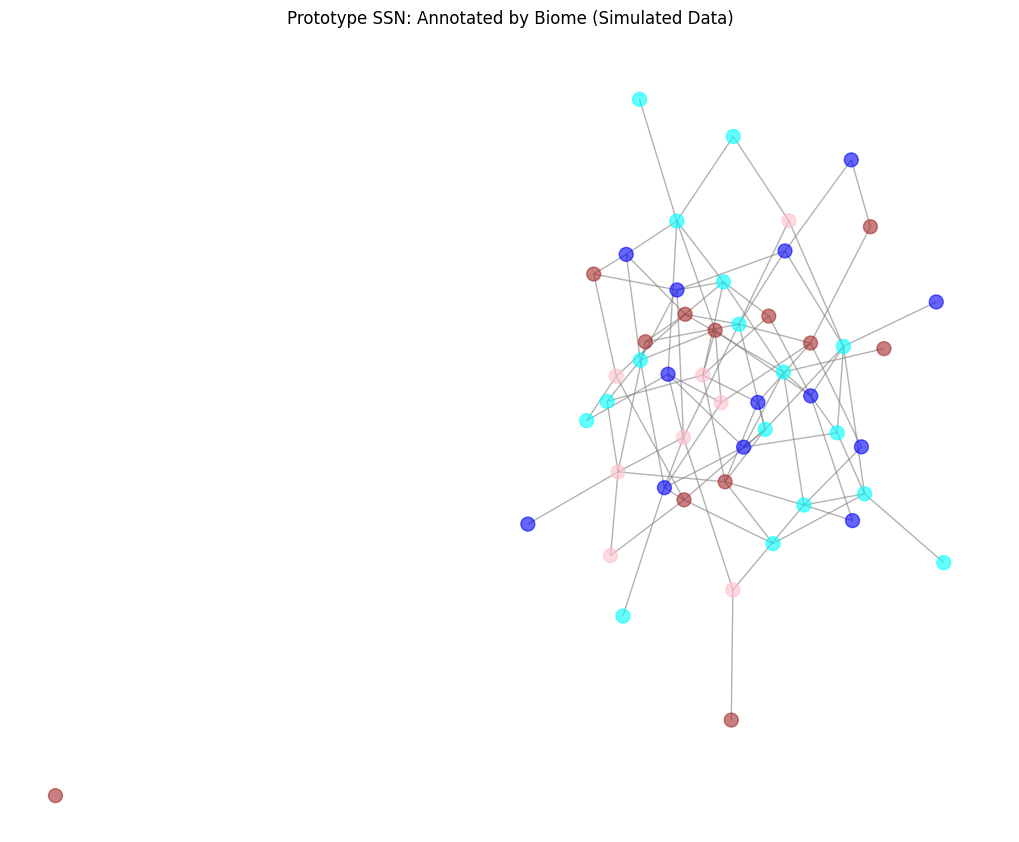

In [ ]:
mock_data = {
    'MGYP': [f'MGYP{i:09d}' for i in range(1, 51)],
    'Biome': [random.choice(['Marine', 'Soil', 'Human Gut', 'Freshwater']) for _ in range(50)],
    'Length': [random.randint(100, 500) for _ in range(50)]
}
df = pd.DataFrame(mock_data)

# Building SSN
G = nx.Graph()
for _, row in df.iterrows():
    G.add_node(row['MGYP'], biome=row['Biome'])

# Create edges based on 'simulated' similarity
for i in range(100):
    u, v = random.sample(list(G.nodes()), 2)
    G.add_edge(u, v)

color_map = {'Marine': 'blue', 'Soil': 'brown', 'Human Gut': 'pink', 'Freshwater': 'cyan'}
colors = [color_map[G.nodes[node]['biome']] for node in G]

plt.figure(figsize=(10, 8))
nx.draw(G, node_color=colors, node_size=100, with_labels=False, edge_color='gray', alpha=0.6)
plt.title("Prototype SSN: Annotated by Biome (Simulated Data)")
plt.show()

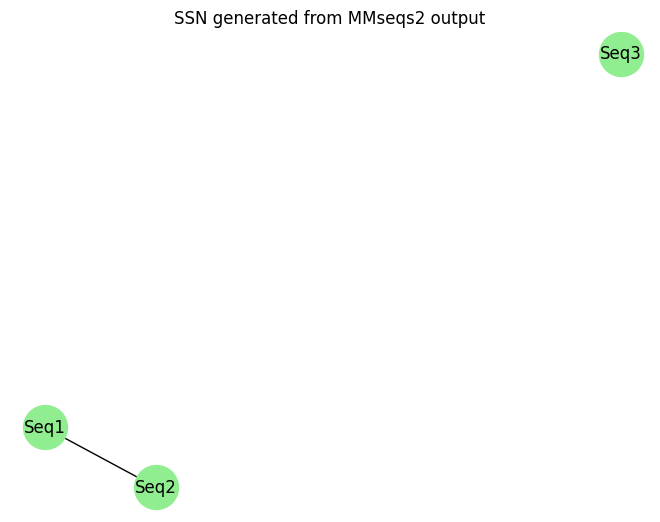

In [ ]:
edges = [
    ("Seq1", "Seq1", 1.0),
    ("Seq2", "Seq2", 1.0),
    ("Seq3", "Seq3", 1.0),
    ("Seq1", "Seq2", 0.85)
]

G = nx.Graph()

for u, v, weight in edges:
    if u != v:
        G.add_edge(u, v, weight=weight)
    else:
        G.add_node(u)

nx.draw(G, with_labels=True, node_color='lightgreen', node_size=1000)
plt.title("SSN generated from MMseqs2 output")
plt.show()

## Validation and Sequence Alignment Pipeline

In [ ]:
!wget "https://rest.uniprot.org/uniprotkb/search?query=metagenome+AND+reviewed:false&format=fasta&size=500" -O real_proteins.faa

--2026-03-27 15:00:14--  https://rest.uniprot.org/uniprotkb/search?query=metagenome+AND+reviewed:false&format=fasta&size=500
Resolving rest.uniprot.org (rest.uniprot.org)... 193.62.193.81
Connecting to rest.uniprot.org (rest.uniprot.org)|193.62.193.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 298131 (291K) [text/plain]
Saving to: ‘real_proteins.faa’

real_proteins.faa   100%[===================>] 291.14K   430KB/s    in 0.7s    

2026-03-27 15:00:15 (430 KB/s) - ‘real_proteins.faa’ saved [298131/298131]



In [ ]:
# Download the MMseqs2 static binary
!wget https://mmseqs.com/latest/mmseqs-linux-sse41.tar.gz
!tar xvfz mmseqs-linux-sse41.tar.gz
!cp mmseqs/bin/mmseqs /usr/local/bin/
!mmseqs

--2026-03-27 15:00:28--  https://mmseqs.com/latest/mmseqs-linux-sse41.tar.gz
Resolving mmseqs.com (mmseqs.com)... 158.247.200.62
Connecting to mmseqs.com (mmseqs.com)|158.247.200.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19046591 (18M) [application/octet-stream]
Saving to: ‘mmseqs-linux-sse41.tar.gz’

mmseqs-linux-sse41. 100%[===================>]  18.16M  20.4MB/s    in 0.9s    

2026-03-27 15:00:29 (20.4 MB/s) - ‘mmseqs-linux-sse41.tar.gz’ saved [19046591/19046591]

mmseqs/
mmseqs/README.md
mmseqs/LICENSE.md
mmseqs/userguide.pdf
mmseqs/bin/
mmseqs/bin/mmseqs
mmseqs/matrices/
mmseqs/matrices/PAM100.out
mmseqs/matrices/PAM60.out
mmseqs/matrices/PAM160.out
mmseqs/matrices/blosum85.out
mmseqs/matrices/VTML120.out
mmseqs/matrices/VTML20.out
mmseqs/matrices/blosum80.out
mmseqs/matrices/blosum95.out
mmseqs/matrices/blosum30.out
mmseqs/matrices/blosum35.out
mmseqs/matrices/PAM180.out
mmseqs/matrices/blosum50.out
mmseqs/matrices/PAM150.out
mmseqs/matrices/VT

In [ ]:
!wget -q "https://rest.uniprot.org/uniprotkb/search?query=metagenome+AND+reviewed:false&format=fasta&size=500" -O real_proteins.faa
!mmseqs createdb real_proteins.faa DB_real
!mkdir -p tmp_real
!mmseqs search DB_real DB_real result_real tmp_real --min-seq-id 0.3 -e 0.001 --search-type 2
!mmseqs convertalis DB_real DB_real result_real real_similarity.tab --format-output query,target,fident,bits,evalue

createdb real_proteins.faa DB_real 

MMseqs Version:                    	76da68ad7577378410c075049e18666fcc94f8d1
Database type                      	0
Shuffle input database             	true
Createdb mode                      	0
Write lookup file                  	1
Offset of numeric ids              	0
Threads                            	2
Compressed                         	0
Mask residues                      	0
Mask residues probability          	0.9
Mask lower case residues           	0
Mask lower letter repeating N times	0
Use GPU                            	0
Verbosity                          	3

Converting sequences
[405] 0s 7ms
Time for merging to DB_real_h: 0h 0m 0s 3ms
Time for merging to DB_real: 0h 0m 0s 3ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 18ms
search DB_real DB_real result_real tmp_real --min-seq-id 0.3 -e 0.001 --search-type 2 

MMseqs Version:                        	76da68ad7577378410c075049e18666fcc94f8d1
Substitution matrix                  

In [ ]:
import pandas as pd
import random
df = pd.read_csv("real_similarity.tab", sep="\t", names=['source', 'target', 'weight', 'bits', 'evalue'])

df_edges = df[df['source'] != df['target']].copy()
df_edges[['source', 'target', 'weight', 'bits']].to_csv("mgnify_real_edges.csv", index=False)

unique_ids = pd.concat([df_edges['source'], df_edges['target']]).unique()
nodes_df = pd.DataFrame({'id': unique_ids})

biomes = ["Marine", "Soil", "Human Gut", "Freshwater", "Hydrothermal Vent"]
nodes_df['biome'] = [random.choice(biomes) for _ in range(len(nodes_df))]

nodes_df.to_csv("mgnify_real_nodes.csv", index=False)

print(f" Success! Created edges for {len(df_edges)} biological relationships.")
print(f" Created node metadata for {len(nodes_df)} unique proteins.")

 Success! Created edges for 7710 biological relationships.
 Created node metadata for 430 unique proteins.
